In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Chosen 3 Large Cap stock
stocks = {
   'SBIN': 'SBIN.NS',
   'RELIANCE': 'RELIANCE.NS',
   'MAHINDRA': 'M&M.NS'
}


end_date = datetime.now()
start_date = datetime.now() - timedelta(days=5*365)

for company, symbol in stocks.items():
   # Download historic data
   df = yf.download(symbol,
                   start=start_date,
                   end=end_date,
                   progress=False)


   df = df[['Close']]
   df.index = df.index.date

   df = df.reset_index()
   df.columns = ['Date', 'Value']

   # Save to CSV
   filename = f'{company}_data.csv'
   df.to_csv(filename, index=False)
   print(f"Created {filename}")

Created SBIN_data.csv
Created RELIANCE_data.csv
Created MAHINDRA_data.csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data = pd.read_csv('RELIANCE_data.csv')
data.head()

,Date,Value
0,2020-01-15,674.714783
1,2020-01-16,680.935669
2,2020-01-17,700.019104
3,2020-01-20,678.478333
4,2020-01-21,679.164612


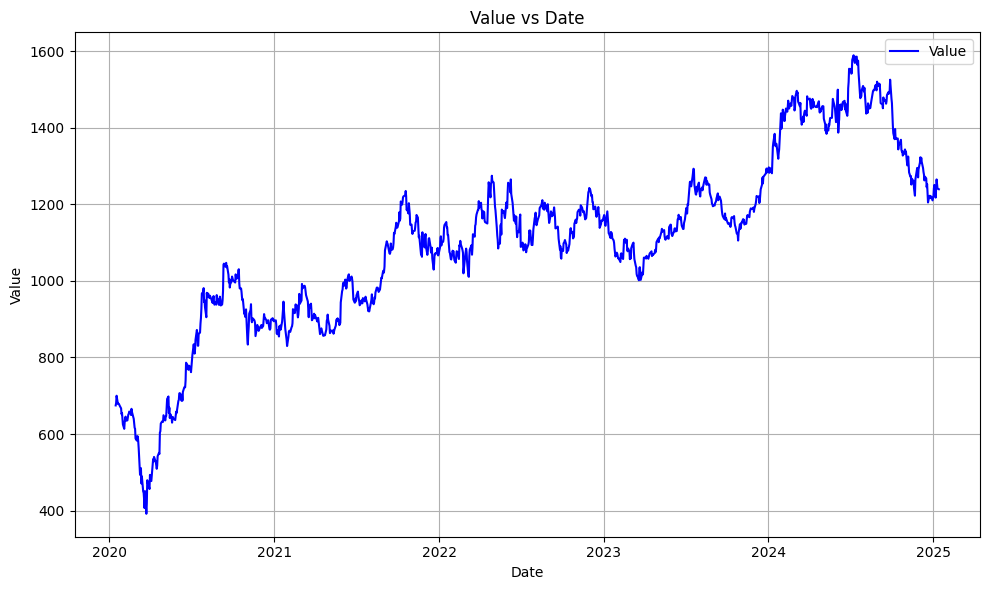

In [30]:
# Changing Date column in datetime format
data['Date'] = pd.to_datetime(data['Date'])

plt.figure(figsize=(10, 6))
plt.plot(data['Date'], data['Value'], linestyle='-', color='b', label='Value')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Value vs Date')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# Step 1: Check Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(data['Value'])

ADF Statistic: -1.9124716772359702
p-value: 0.3262169773306288
The series is not stationary.


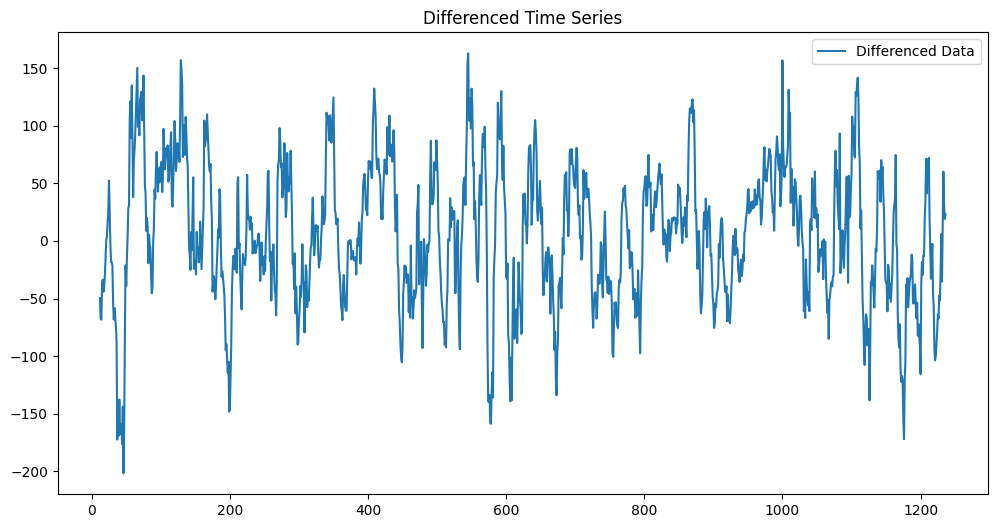

ADF Statistic: -7.1589196671372175
p-value: 3.0035621216622897e-10
The series is stationary.


<Figure size 1200x600 with 0 Axes>

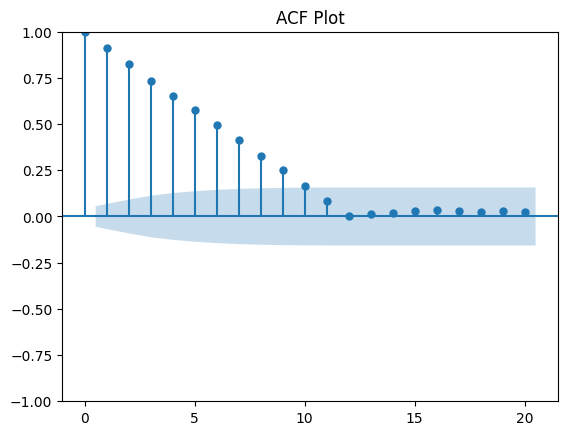

<Figure size 1200x600 with 0 Axes>

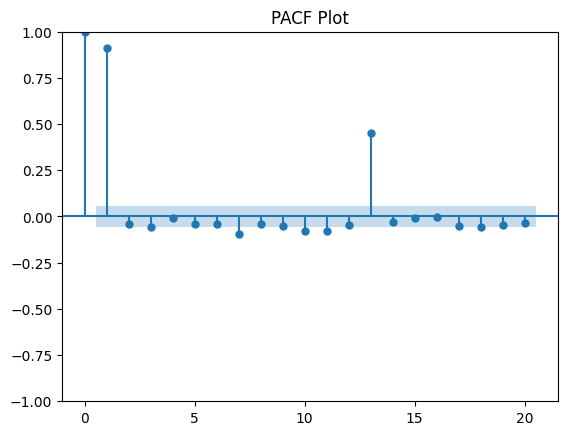

In [26]:
# If not stationary, perform differencing
# Step 1: Differencing the data (Seasonal differencing with lag=12)
value_series = data['Value']
data_diff = value_series.diff(12).dropna()


plt.figure(figsize=(12, 6))
plt.plot(data_diff, label="Differenced Data")
plt.title("Differenced Time Series")
plt.legend()
plt.show()

# Check stationarity of the differenced data
check_stationarity(data_diff)

# Step 2: ACF and PACF Plots
plt.figure(figsize=(12, 6))
plot_acf(data_diff, lags=20)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(data_diff, lags=20)
plt.title("PACF Plot")
plt.show()

In [27]:
# order = (p,d,q)

In [28]:

# AR Model
ar_model = ARIMA(value_series, order=(1, 0, 0))  # Change 'p' based on PACF
ar_fit = ar_model.fit()
ar_pred = ar_fit.predict(start=0, end=len(value_series)-1)
ar_forecast = ar_fit.forecast(steps=12)

# MA Model
ma_model = ARIMA(value_series, order=(0, 0, 9))  # Change 'q' based on ACF
ma_fit = ma_model.fit()
ma_pred = ma_fit.predict(start=0, end=len(value_series)-1)
ma_forecast = ma_fit.forecast(steps=12)

# ARMA Model
arma_model = ARIMA(value_series, order=(1, 0, 9))  # Change 'p' and 'q' based on PACF and ACF
arma_fit = arma_model.fit()
arma_pred = arma_fit.predict(start=0, end=len(value_series)-1)
arma_forecast = arma_fit.forecast(steps=12)

# ARIMA Model
arima_model = ARIMA(value_series, order=(1, 1, 9))  # Adjust 'd' for differencing
arima_fit = arima_model.fit()
arima_pred = arima_fit.predict(start=1, end=len(value_series), typ='levels')
arima_forecast = arima_fit.forecast(steps=12)

# # SARIMA Model
# sarima_model = SARIMAX(value_series, order=(1, 1, 9), seasonal_order=(1, 1, 9, 12))
# sarima_fit = sarima_model.fit()
# sarima_pred = sarima_fit.predict(start=1, end=len(value_series))
# sarima_forecast = sarima_fit.forecast(steps=12)

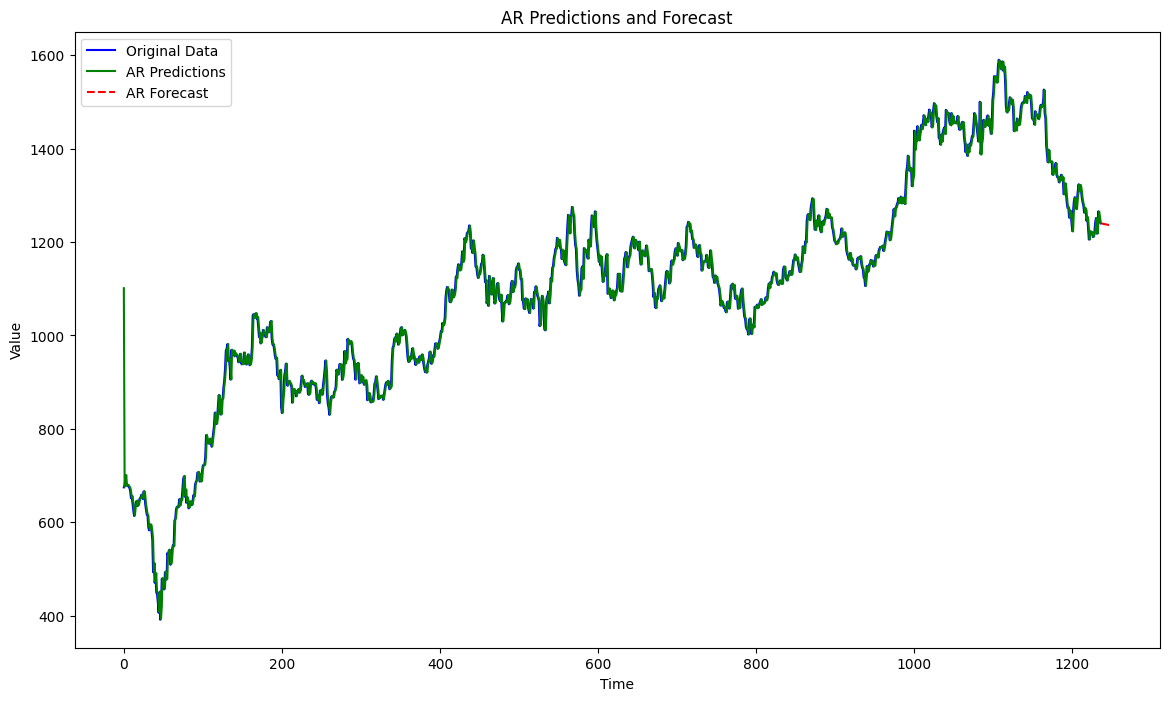

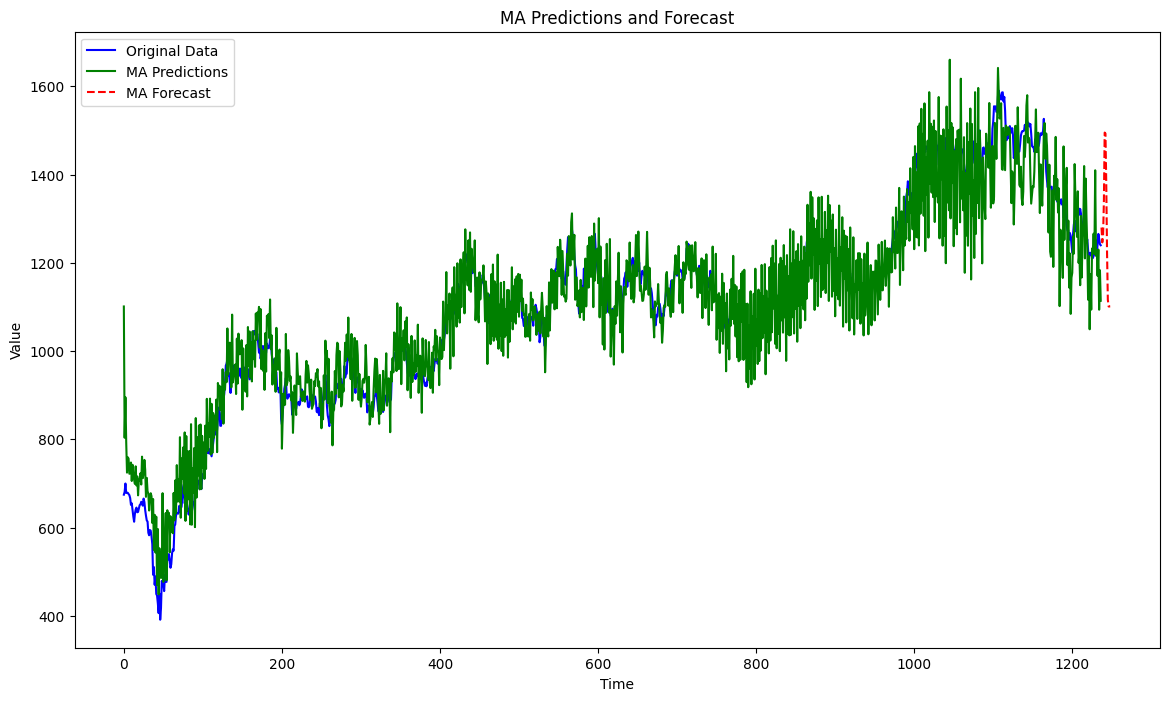

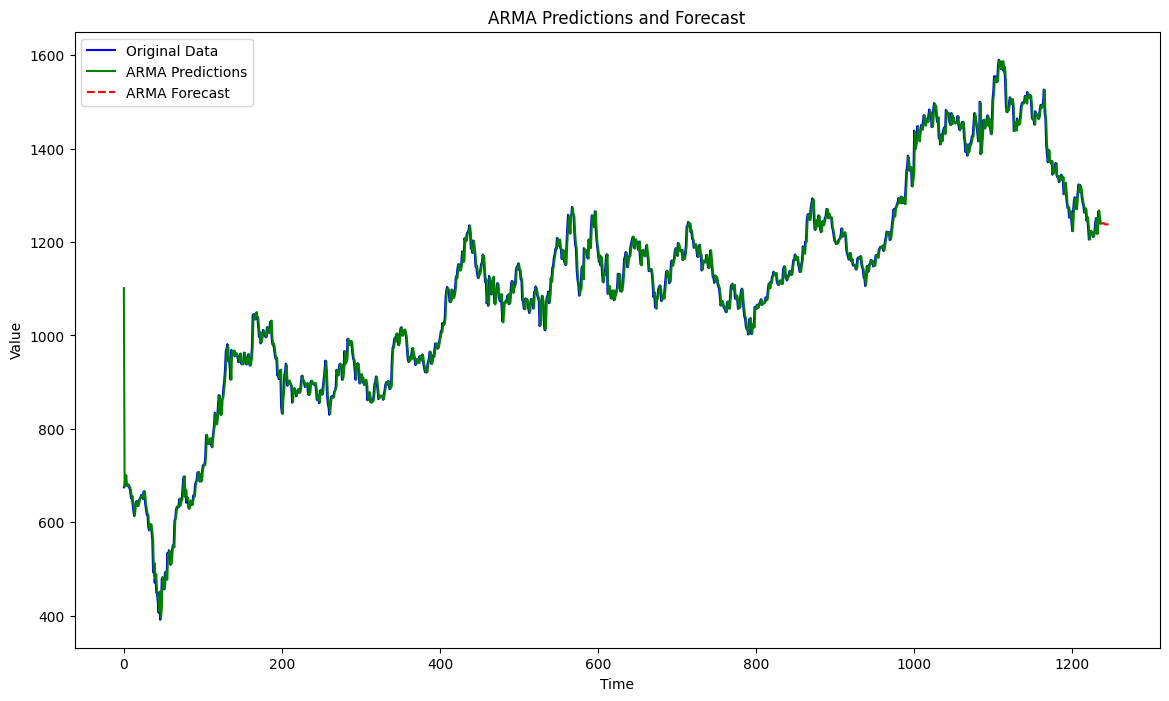

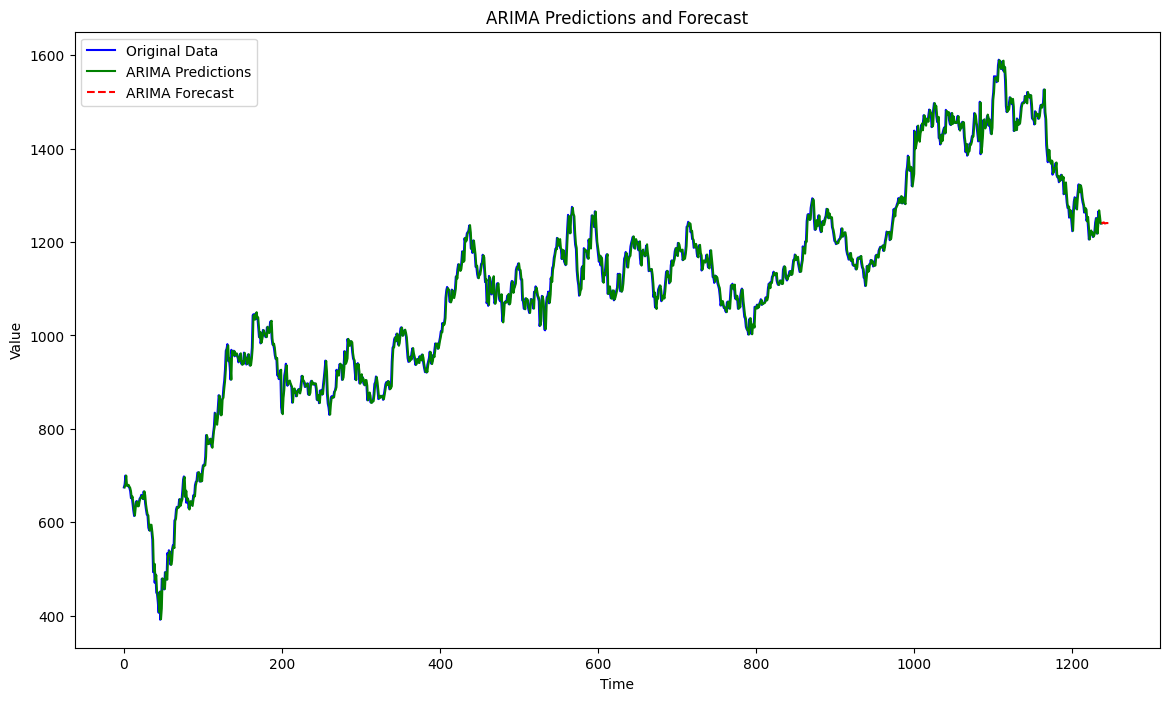

In [29]:
# Plot Predictions and Forecasts
models = {
    "AR": (ar_pred, ar_forecast),
    "MA": (ma_pred, ma_forecast),
    "ARMA": (arma_pred, arma_forecast),
    "ARIMA": (arima_pred, arima_forecast),
    # "SARIMA": (sarima_pred, sarima_forecast),
}

for model_name, (predictions, forecast) in models.items():
    plt.figure(figsize=(14, 8))
    plt.plot(value_series, label="Original Data", color="blue")
    plt.plot(predictions, label=f"{model_name} Predictions", color="green")
    plt.plot(
        range(len(value_series), len(value_series) + len(forecast)),
        forecast,
        label=f"{model_name} Forecast",
        color="red",
        linestyle="dashed",
    )
    plt.title(f"{model_name} Predictions and Forecast")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

#Similarly we can do the above analysis for other stocks( Mahindra & SBIN)  too, we just need to change the (p,d,q) value accordingly#